# Precipitation Change and Flood Activity Across U.S. Counties

## Project Overview

This project examines the relationship between precipitation patterns and flood
activity across U.S. counties. The main research question is:

**Are counties where precipitation conditions have changed more also experiencing
changes in flooding?**

The project uses county-level precipitation data and historical Flood and Flash Flood event data from the National Oceanic and Atmospheric Administration (NOAA). I am doing this analysis to examine whether changes in precipitation can help explain differences in flood activity across counties. Python will be used for data cleaning, exploratory data analysis (EDA), visualization, and later development and evaluation of machine learning models to examine whether precipitation patterns can help predict county-level flood activity.

---

## Data Sources

### 1. County-Level Precipitation Data

**Source:** NOAA National Centers for Environmental Information (NCEI),
nClimGrid-Daily.

**Data access:**  
https://www.ncei.noaa.gov/data/nclimgrid-daily/access/averages/

The precipitation variable used in this project is **PRCP**. County-level
precipitation data were downloaded for **2000–2025** using Python. The original
NOAA monthly files were downloaded and organized into one CSV file for each year,
from `prcp_2000.csv` through `prcp_2025.csv`.

The precipitation data contain county names and county identifiers. During exploratory analysis, I found that these identifiers are not directly aligned with the official county FIPS codes used in the Storm Events data. The geographic identifiers will therefore need to be standardized before the two datasets are combined.

### 2. Flood and Flash Flood Data

**Source:** NOAA National Centers for Environmental Information (NCEI),
Storm Events Database.

**Data download:**  
https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/

**Storm Events information:**  
https://www.ncei.noaa.gov/stormevents/

Storm Events data were downloaded using Python. Only events classified as
**Flood** or **Flash Flood** and reported at the county level were retained.

During initial exploration of the data, I found that many Flood records before
2007 were reported using NOAA forecast zones rather than counties. Beginning in
2007, the Flood records used in this project were consistently reported at the
county level. Therefore, the county-level flood dataset covers **2007–2025**.

The cleaned flood-event data were saved as one CSV file for each year, from
`flood_events_2007.csv` through `flood_events_2025.csv`.

---

## Study Period

The precipitation data cover **2000–2025**, while the county-level flood data
cover **2007–2025**. Therefore, **2007–2025 will be used as the common period
when the precipitation and flood datasets are combined for analysis**.

The earlier precipitation data from 2000–2006 are retained as part of the raw
precipitation dataset and may also be useful for examining longer-term
precipitation patterns.

---

### Data Acquisition and Preparation
The two NOAA datasets were downloaded and prepared using Python. For precipitation, monthly county-level PRCP files were downloaded for each year from 2000 through 2025 and combined into one file for each year. For Storm Events, I first examined how Flood and Flash Flood records were geographically reported. Because earlier Flood records were often reported by forecast zone rather than county, I use 2007–2025 as the consistent county-level period. Only Flood and Flash Flood records with county-based geographic reporting were retained.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Download county-level precipitation data for 2000-2025
# Combine the 12 monthly files and save one file for each year
columns = (
    ["type", "fips", "county", "year", "month", "variable"]
    + [f"day_{i}" for i in range(1, 32)]
)

for year in range(2000, 2026):

    output_file = f"../data/prcp_{year}.csv"

    # Skip years already successfully saved
    if os.path.exists(output_file):
        print(f"{year} already exists - skipping")
        continue

    yearly_data = []

    for month in range(1, 13):

        url = (
            f"https://www.ncei.noaa.gov/data/nclimgrid-daily/"
            f"access/averages/{year}/"
            f"prcp-{year}{month:02d}-cty-scaled.csv"
        )

        temp = pd.read_csv(
            url,
            header=None,
            names=columns,
            na_values=-999.99
        )

        yearly_data.append(temp)

    year_df = pd.concat(yearly_data, ignore_index=True)

    year_df.to_csv(
        output_file,
        index=False
    )

    print("SAVED", year)

2000 already exists - skipping
2001 already exists - skipping
2002 already exists - skipping
2003 already exists - skipping
2004 already exists - skipping
2005 already exists - skipping
2006 already exists - skipping
2007 already exists - skipping
2008 already exists - skipping
2009 already exists - skipping
2010 already exists - skipping
2011 already exists - skipping
2012 already exists - skipping
2013 already exists - skipping
2014 already exists - skipping
2015 already exists - skipping
2016 already exists - skipping
2017 already exists - skipping
2018 already exists - skipping
2019 already exists - skipping
2020 already exists - skipping
2021 already exists - skipping
2022 already exists - skipping
2023 already exists - skipping
2024 already exists - skipping
2025 already exists - skipping


### Flood and Flash Flood Data Preparation

Earlier Storm Events records did not consistently report Flood events at the county level. Initial inspection showed that forecast-zone reporting was common before 2007. Therefore, I use 2007–2025 as the consistent county-level period for the Flood and Flash Flood data.

In [3]:
# Download Flood and Flash Flood records for 2007-2025
# Keep county-level records and create county FIPS codes
versions = {
    2017: "20260519",
    2022: "20260625",
    2024: "20260728",
    2025: "20260819"
}

base_url = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"

# Variables we want to keep
keep_columns = [
    "YEAR",
    "MONTH_NAME",
    "EVENT_ID",
    "STATE",
    "STATE_FIPS",
    "EVENT_TYPE",
    "CZ_TYPE",
    "CZ_FIPS",
    "CZ_NAME",
    "BEGIN_DATE_TIME",
    "END_DATE_TIME",
    "DAMAGE_PROPERTY",
    "DAMAGE_CROPS",
    "INJURIES_DIRECT",
    "DEATHS_DIRECT",
    "BEGIN_LAT",
    "BEGIN_LON",
    "END_LAT",
    "END_LON"
]

# Consistent county-level period
for year in range(2007, 2026):

    output_file = f"../data/flood_events_{year}.csv"

    # Skip years already successfully saved
    if os.path.exists(output_file):
        print(f"{year} already exists - skipping")
        continue

    version = versions.get(year, "20260323")

    url = (
        f"{base_url}"
        f"StormEvents_details-ftp_v1.0_d{year}_c{version}.csv.gz"
    )

    try:
        storm = pd.read_csv(url, usecols=keep_columns)

        # Keep only Flood and Flash Flood
        flood = storm[
            storm["EVENT_TYPE"].isin(["Flood", "Flash Flood"])
        ].copy()

        # Keep only county-based records
        flood = flood[
            flood["CZ_TYPE"] == "C"
        ].copy()

        # Construct 5-digit county FIPS
        flood["STATE_FIPS"] = (
            flood["STATE_FIPS"]
            .astype(int)
            .astype(str)
            .str.zfill(2)
        )

        flood["CZ_FIPS"] = (
            flood["CZ_FIPS"]
            .astype(int)
            .astype(str)
            .str.zfill(3)
        )

        flood["county_fips"] = (
            flood["STATE_FIPS"] + flood["CZ_FIPS"]
        )

        # Save the cleaned year
        flood.to_csv(output_file, index=False)

        print(
            f"SAVED {year}: "
            f"{len(flood)} county flood records"
        )

    except Exception as e:
        print(f"ERROR {year}: {e}")

print("FINISHED")

2007 already exists - skipping
2008 already exists - skipping
2009 already exists - skipping
2010 already exists - skipping
2011 already exists - skipping
2012 already exists - skipping
2013 already exists - skipping
2014 already exists - skipping
2015 already exists - skipping
2016 already exists - skipping
2017 already exists - skipping
2018 already exists - skipping
2019 already exists - skipping
2020 already exists - skipping
2021 already exists - skipping
2022 already exists - skipping
2023 already exists - skipping
2024 already exists - skipping
2025 already exists - skipping
FINISHED


In [4]:
# Check that the precipitation and flood files were saved 
files = os.listdir("../data")

prcp_files = sorted([
    f for f in files
    if f.startswith("prcp_")
])

flood_files = sorted([
    f for f in files
    if f.startswith("flood_events_")
])

print("Precipitation files:", len(prcp_files))
print("Flood event files:", len(flood_files))
print("Total CSV files:", len(prcp_files) + len(flood_files))

print("\nPrecipitation:")
print(prcp_files[0], "to", prcp_files[-1])

print("\nFlood events:")
print(flood_files[0], "to", flood_files[-1])

Precipitation files: 26
Flood event files: 19
Total CSV files: 45

Precipitation:
prcp_2000.csv to prcp_2025.csv

Flood events:
flood_events_2007.csv to flood_events_2025.csv


# Exploratory Data Analysis (EDA)

The exploratory data analysis is organized into two parts. First, I examine the county-level precipitation data to understand its structure, temporal coverage, geographic coverage, and missing values. Second, I examine the NOAA Storm Events data for Flood and Flash Flood events. After examining the two datasets separately, I will evaluate their temporal and geographic overlap before combining them for further analysis.

## 1. Precipitation Data

The precipitation dataset contains county-level daily precipitation observations organized by year and month. The data cover 2000–2025. Before using these data for analysis, I first examine the structure of the files, available years and months, geographic coverage, and missing values.

In [5]:
# Load all precipitation files from 2000 to 2025

prcp_files = [
    f"../data/prcp_{year}.csv"
    for year in range(2000, 2026)
]

prcp = pd.concat(
    [pd.read_csv(file) for file in prcp_files],
    ignore_index=True
)

prcp.head()

,type,fips,county,year,month,variable,day_1,day_2,day_3,day_4,...,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31
0,cty,1001,AL: Autauga,2000,1,PRCP,0.00,0.00,0.00,22.79,...,0.00,22.56,9.40,0.00,0.0,0.0,4.50,19.27,3.35,0.00
1,cty,1003,AL: Baldwin County,2000,1,PRCP,0.00,0.00,0.00,4.51,...,0.00,11.77,17.00,0.00,0.0,0.0,4.85,4.39,1.85,1.03
2,cty,1005,AL: Barbour County,2000,1,PRCP,0.00,0.00,0.00,4.73,...,0.00,16.51,33.06,0.00,0.0,0.0,0.00,8.73,6.47,0.23
3,cty,1007,AL: Bibb County,2000,1,PRCP,0.48,0.02,0.00,28.23,...,0.00,16.93,1.30,0.00,0.0,0.0,5.82,20.40,2.95,0.00
4,cty,1009,AL: Blount County,2000,1,PRCP,0.00,0.00,1.51,32.32,...,0.31,23.31,0.00,0.01,0.0,0.0,2.51,13.74,5.80,0.00


In [6]:
# Examine the structure of the precipitation dataset
prcp.info()

<class 'pandas.DataFrame'>
RangeIndex: 969384 entries, 0 to 969383
Data columns (total 37 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   type      969384 non-null  str    
 1   fips      969384 non-null  int64  
 2   county    969384 non-null  str    
 3   year      969384 non-null  int64  
 4   month     969384 non-null  int64  
 5   variable  969384 non-null  str    
 6   day_1     969384 non-null  float64
 7   day_2     969384 non-null  float64
 8   day_3     969384 non-null  float64
 9   day_4     969384 non-null  float64
 10  day_5     969384 non-null  float64
 11  day_6     969384 non-null  float64
 12  day_7     969384 non-null  float64
 13  day_8     969384 non-null  float64
 14  day_9     969384 non-null  float64
 15  day_10    969384 non-null  float64
 16  day_11    969384 non-null  float64
 17  day_12    969384 non-null  float64
 18  day_13    969384 non-null  float64
 19  day_14    969384 non-null  float64
 20  day_15    96938

In [7]:
# Examine temporal coverage of the precipitation data

print("First year:", prcp["year"].min())
print("Last year:", prcp["year"].max())
print("Months:", sorted(prcp["month"].unique()))

First year: 2000
Last year: 2025
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### Temporal Coverage and Resolution
The precipitation data cover the period from 2000 to 2025 and include all 12 months of each year. The original data contain daily precipitation values organized into monthly county-level records. For this project, the daily values will be aggregated to monthly and annual precipitation totals.

In [8]:
# Examine spatial coverage of the precipitation data

print("Number of unique counties:", prcp["fips"].nunique())
print("First 10 county records:")
print(prcp[["fips", "county"]].drop_duplicates().head(10))

Number of unique counties: 3107
First 10 county records:
   fips               county
0  1001          AL: Autauga
1  1003   AL: Baldwin County
2  1005   AL: Barbour County
3  1007      AL: Bibb County
4  1009    AL: Blount County
5  1011   AL: Bullock County
6  1013    AL: Butler County
7  1015   AL: Calhoun County
8  1017  AL: Chambers County
9  1019  AL: Cherokee County


### Spatial Coverage and Resolution
The precipitation data are organized at the county level and contain 3,107 unique county records. The dataset provides county names and geographic identifiers. During the comparison with the Storm Events data, I found that these identifiers are not directly aligned with the official county FIPS codes used in the flood dataset. Therefore, the geographic identifiers will need to be standardized before the two datasets are combined.

In [9]:
# Examine state coverage of the precipitation data

prcp["state"] = prcp["county"].str.split(":").str[0]

print("Number of states/areas:", prcp["state"].nunique())
print("States/areas:")
print(sorted(prcp["state"].unique()))

Number of states/areas: 49
States/areas:
['AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


In [10]:
# Check missing values in the precipitation data

print("Total missing values:", prcp.isnull().sum().sum())

print("\nMissing values by column:")
print(prcp.isnull().sum())

Total missing values: 543725

Missing values by column:
type             0
fips             0
county           0
year             0
month            0
variable         0
day_1            0
day_2            0
day_3            0
day_4            0
day_5            0
day_6            0
day_7            0
day_8            0
day_9            0
day_10           0
day_11           0
day_12           0
day_13           0
day_14           0
day_15           0
day_16           0
day_17           0
day_18           0
day_19           0
day_20           0
day_21           0
day_22           0
day_23           0
day_24           0
day_25           0
day_26           0
day_27           0
day_28           0
day_29       59033
day_30       80782
day_31      403910
state            0
dtype: int64


### Missing Values

The missing values are concentrated in `day_29`, `day_30`, and `day_31`. This mainly occurs because the dataset uses 31 daily columns for every month, while some months have fewer than 31 days. Therefore, these missing values mostly reflect differences in the number of days in each month rather than missing county or time information. The earlier daily columns do not contain missing values.

### Preparing Precipitation for Visualization

Daily precipitation values are provided in separate daily columns (day_1 through day_31). I first summed the daily values to calculate monthly precipitation for each county. I then summed the monthly values by county and year to create annual precipitation totals. These annual values will be used to examine precipitation patterns over time.

In [11]:
# Identify daily precipitation columns

day_columns = [col for col in prcp.columns if col.startswith("day_")]

print("Number of daily columns:", len(day_columns))
print(day_columns)

Number of daily columns: 31
['day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6', 'day_7', 'day_8', 'day_9', 'day_10', 'day_11', 'day_12', 'day_13', 'day_14', 'day_15', 'day_16', 'day_17', 'day_18', 'day_19', 'day_20', 'day_21', 'day_22', 'day_23', 'day_24', 'day_25', 'day_26', 'day_27', 'day_28', 'day_29', 'day_30', 'day_31']


In [12]:
# Calculate monthly precipitation total for each county

prcp["monthly_prcp"] = prcp[day_columns].sum(axis=1)

prcp[["fips", "county", "year", "month", "monthly_prcp"]].head()

,fips,county,year,month,monthly_prcp
0,1001,AL: Autauga,2000,1,140.17
1,1003,AL: Baldwin County,2000,1,65.51
2,1005,AL: Barbour County,2000,1,116.59
3,1007,AL: Bibb County,2000,1,128.42
4,1009,AL: Blount County,2000,1,139.66


In [13]:
# Calculate annual precipitation for each county

annual_county_prcp = (
    prcp.groupby(["fips", "year"])["monthly_prcp"]
    .sum()
    .reset_index()
)

annual_county_prcp.head()

,fips,year,monthly_prcp
0,1001,2000,1010.60
1,1001,2001,1530.28
2,1001,2002,1304.34
3,1001,2003,1690.33
4,1001,2004,1302.56


In [14]:
# Rename precipitation column to represent annual values

annual_county_prcp = annual_county_prcp.rename(
    columns={"monthly_prcp": "annual_prcp"}
)

annual_county_prcp.head()

,fips,year,annual_prcp
0,1001,2000,1010.60
1,1001,2001,1530.28
2,1001,2002,1304.34
3,1001,2003,1690.33
4,1001,2004,1302.56


In [15]:
# Calculate average annual precipitation across counties

annual_mean_prcp = (
    annual_county_prcp.groupby("year")["annual_prcp"]
    .mean()
    .reset_index()
)

annual_mean_prcp.head()

,year,annual_prcp
0,2000,901.026315
1,2001,938.845504
2,2002,971.270103
3,2003,1028.097811
4,2004,1075.882591


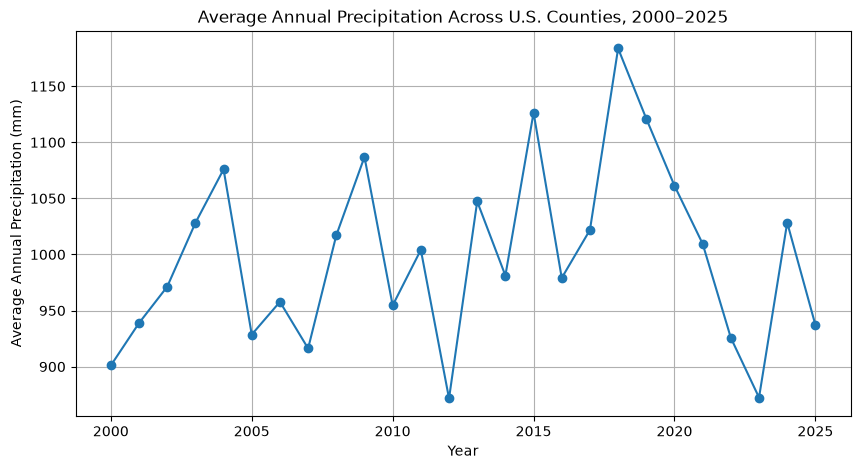

In [16]:
# Plot average annual precipitation over time

plt.figure(figsize=(10, 5))

plt.plot(
    annual_mean_prcp["year"],
    annual_mean_prcp["annual_prcp"],
    marker="o"
)

plt.title("Average Annual Precipitation Across U.S. Counties, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Average Annual Precipitation (mm)")
plt.grid(True)

plt.show()

### Annual Precipitation Pattern

Average annual precipitation varies considerably from year to year between 2000 and 2025. Some years show relatively high precipitation, while others are much lower. This figure provides an overall view of precipitation variability across the study period. Because the project focuses on differences among counties, the next step is to examine how precipitation patterns vary spatially across counties.

In [17]:
# Calculate average annual precipitation for each county

county_mean_prcp = (
    annual_county_prcp.groupby("fips")["annual_prcp"]
    .mean()
    .reset_index()
)

county_mean_prcp.head()

,fips,annual_prcp
0,1001,1388.230769
1,1003,1577.350385
2,1005,1342.564231
3,1007,1390.316923
4,1009,1458.494231


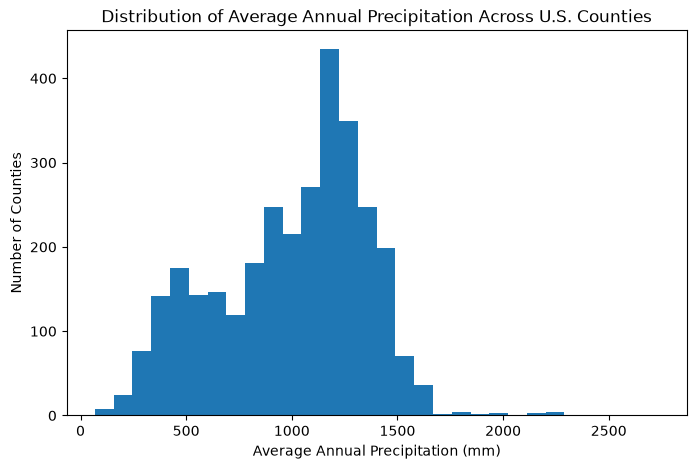

In [18]:
# Plot the distribution of average annual precipitation across counties

plt.figure(figsize=(8, 5))

plt.hist(county_mean_prcp["annual_prcp"], bins=30)

plt.title("Distribution of Average Annual Precipitation Across U.S. Counties")
plt.xlabel("Average Annual Precipitation (mm)")
plt.ylabel("Number of Counties")

plt.show()

### County-Level Precipitation Variation

Average annual precipitation differs substantially across U.S. counties. Many counties fall within the middle of the distribution, while some counties experience much lower or much higher annual precipitation. This variation shows that precipitation conditions are not the same across counties and supports examining county-level changes over time rather than relying only on the national average.

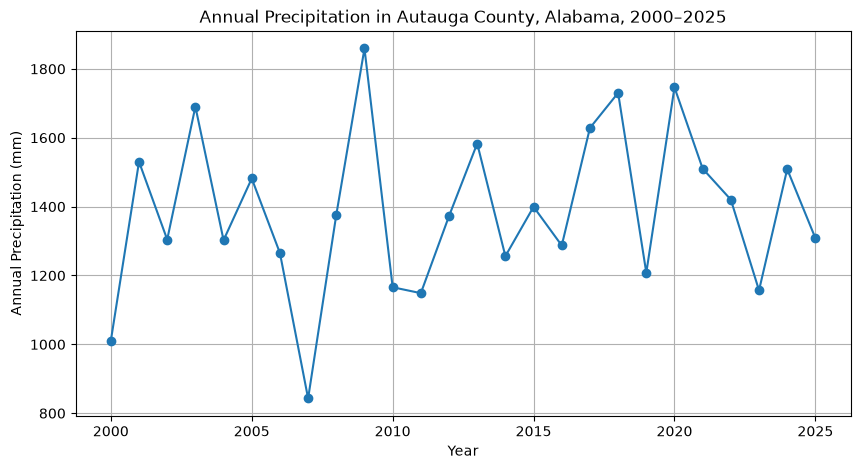

In [19]:
# Examine annual precipitation over time for one county

example_county = annual_county_prcp[
    annual_county_prcp["fips"] == 1001
]

plt.figure(figsize=(10, 5))

plt.plot(
    example_county["year"],
    example_county["annual_prcp"],
    marker="o"
)

plt.title("Annual Precipitation in Autauga County, Alabama, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Annual Precipitation (mm)")
plt.grid(True)

plt.show()

### Example of County-Level Precipitation Variation

Annual precipitation in Autauga County, Alabama varies considerably from year to year between 2000 and 2025. Some years are much wetter or drier than others. This example shows why precipitation change needs to be measured across the full study period rather than using only individual years.

In [20]:
# Calculate precipitation trend for Autauga County

slope, intercept = np.polyfit(
    example_county["year"],
    example_county["annual_prcp"],
    1
)

print("Precipitation trend:", slope, "mm per year")

Precipitation trend: 5.197811965812463 mm per year


### Measuring County-Level Precipitation Change

As an exploratory measure of precipitation change, I calculated a linear trend for each county using annual precipitation from 2000 to 2025. The trend is expressed in millimeters per year. A positive value indicates an overall increase in annual precipitation, while a negative value indicates an overall decrease. For the later comparison with flood activity, precipitation trends will be calculated using the common study period of 2007–2025.

In [21]:
# Calculate precipitation trend for each county

precip_trends = []

for fips, group in annual_county_prcp.groupby("fips"):
    slope, intercept = np.polyfit(
        group["year"],
        group["annual_prcp"],
        1
    )
    
    precip_trends.append([fips, slope])

precip_trends = pd.DataFrame(
    precip_trends,
    columns=["fips", "prcp_trend"]
)

precip_trends.head()

,fips,prcp_trend
0,1001,5.197812
1,1003,4.119217
2,1005,6.141945
3,1007,2.220431
4,1009,2.704393


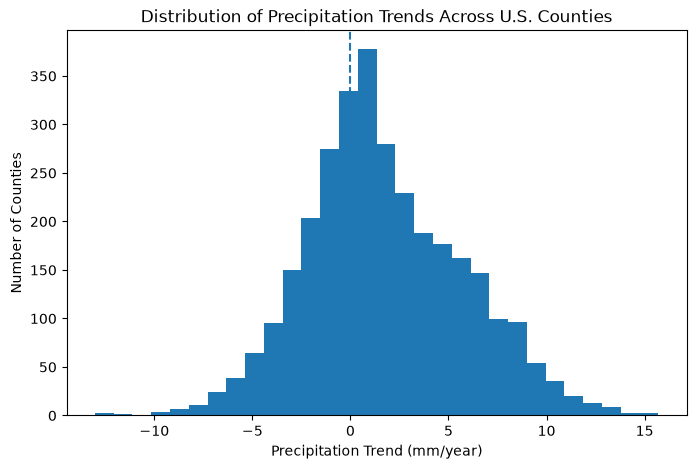

In [22]:
# Plot the distribution of precipitation trends across counties

plt.figure(figsize=(8, 5))

plt.hist(precip_trends["prcp_trend"], bins=30)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Precipitation Trends Across U.S. Counties")
plt.xlabel("Precipitation Trend (mm/year)")
plt.ylabel("Number of Counties")

plt.show()

### Distribution of County Precipitation Trends

Precipitation trends vary across U.S. counties. Some counties show decreasing precipitation over time, while others show increasing precipitation. Many counties are concentrated around small changes, but there are also counties with stronger positive or negative trends. This variation provides the county-level precipitation change measure that will later be compared with changes in flood activity.

## 2. Flood and Flash Flood Data

The second dataset contains Flood and Flash Flood events from the NOAA Storm Events Database. The current downloaded files cover 2007–2025. I first examine the structure, temporal coverage, geographic coverage, and event types before preparing the data for county-level analysis.

In [23]:
# Load all Flood and Flash Flood files from 2007 to 2025

flood_files = [
    f"../data/flood_events_{year}.csv"
    for year in range(2007, 2026)
]

flood = pd.concat(
    [pd.read_csv(file) for file in flood_files],
    ignore_index=True
)

flood.head()

,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,BEGIN_DATE_TIME,END_DATE_TIME,INJURIES_DIRECT,DEATHS_DIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,county_fips
0,52835,ARIZONA,4,2007,July,Flood,C,25,YAVAPAI,31-JUL-07 17:06:00,31-JUL-07 18:30:00,0,0,0.00K,0.00K,34.70,-112.0200,34.7000,-112.0200,4025
1,52836,ARIZONA,4,2007,July,Flood,C,25,YAVAPAI,31-JUL-07 17:30:00,31-JUL-07 19:00:00,0,0,0.00K,0.00K,34.59,-112.0900,34.5900,-112.0900,4025
2,55119,ARIZONA,4,2007,August,Flood,C,1,APACHE,01-AUG-07 19:00:00,01-AUG-07 20:30:00,0,0,0.00K,0.00K,34.51,-109.3800,34.5100,-109.3800,4001
3,39186,WYOMING,56,2007,August,Flash Flood,C,21,LARAMIE,03-AUG-07 14:58:00,03-AUG-07 16:30:00,0,0,0.00K,0.00K,41.17,-104.0700,41.1700,-104.0700,56021
4,39006,ILLINOIS,17,2007,June,Flash Flood,C,97,LAKE,08-JUN-07 04:29:00,08-JUN-07 08:00:00,0,0,0.00K,0.00K,42.45,-87.8888,42.4611,-87.8662,17097


In [24]:
# Examine the structure of the Flood and Flash Flood dataset

flood.info()

<class 'pandas.DataFrame'>
RangeIndex: 123525 entries, 0 to 123524
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   EVENT_ID         123525 non-null  int64  
 1   STATE            123525 non-null  str    
 2   STATE_FIPS       123525 non-null  int64  
 3   YEAR             123525 non-null  int64  
 4   MONTH_NAME       123525 non-null  str    
 5   EVENT_TYPE       123525 non-null  str    
 6   CZ_TYPE          123525 non-null  str    
 7   CZ_FIPS          123525 non-null  int64  
 8   CZ_NAME          123525 non-null  str    
 9   BEGIN_DATE_TIME  123525 non-null  str    
 10  END_DATE_TIME    123525 non-null  str    
 11  INJURIES_DIRECT  123525 non-null  int64  
 12  DEATHS_DIRECT    123525 non-null  int64  
 13  DAMAGE_PROPERTY  123499 non-null  str    
 14  DAMAGE_CROPS     123525 non-null  str    
 15  BEGIN_LAT        123525 non-null  float64
 16  BEGIN_LON        123525 non-null  float64
 17  EN

In [25]:
# Examine temporal coverage of the Flood and Flash Flood data

print("First year:", flood["YEAR"].min())
print("Last year:", flood["YEAR"].max())
print("Years:", sorted(flood["YEAR"].unique()))

First year: 2007
Last year: 2025
Years: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### Temporal Coverage and Resolution
The Flood and Flash Flood data cover the period from 2007 to 2025, with records available for every year during this period. Each row represents an individual Flood or Flash Flood event reported in the NOAA Storm Events Database. For the later analysis, these event records will be aggregated to annual county-level flood counts. The period 2007–2025 overlaps with the precipitation dataset and will be used as the common time period when the two datasets are compared.

In [26]:
# Examine geographic record types

print(flood["CZ_TYPE"].value_counts())

CZ_TYPE
C    123525
Name: count, dtype: int64


### Geographic Record Type
All Flood and Flash Flood records in the prepared dataset are county-based (CZ_TYPE = C). This is important because the precipitation data are also organized at the county level. However, the geographic identifiers in the two datasets are not directly aligned, so they will need to be standardized before the datasets are combined.

In [27]:
# Examine county coverage of the Flood and Flash Flood data

print("Number of unique counties:", flood["county_fips"].nunique())

print("First 10 county records:")
print(
    flood[["county_fips", "STATE", "CZ_NAME"]]
    .drop_duplicates()
    .head(10)
)

Number of unique counties: 3237
First 10 county records:
    county_fips     STATE     CZ_NAME
0          4025   ARIZONA     YAVAPAI
2          4001   ARIZONA      APACHE
3         56021   WYOMING     LARAMIE
4         17097  ILLINOIS        LAKE
5         31127  NEBRASKA      NEMAHA
6         12109   FLORIDA   ST. JOHNS
7         17037  ILLINOIS     DE KALB
8         31151  NEBRASKA      SALINE
9         31147  NEBRASKA  RICHARDSON
10        17197  ILLINOIS        WILL


In [28]:
# Examine state coverage of the Flood and Flash Flood data

print("Number of states/areas:", flood["STATE"].nunique())

print("States/areas:")
print(sorted(flood["STATE"].unique()))

Number of states/areas: 55
States/areas:
['ALABAMA', 'ALASKA', 'AMERICAN SAMOA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA', 'COLORADO', 'CONNECTICUT', 'DELAWARE', 'DISTRICT OF COLUMBIA', 'FLORIDA', 'GEORGIA', 'GUAM', 'HAWAII', 'IDAHO', 'ILLINOIS', 'INDIANA', 'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND', 'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI', 'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA', 'NEW HAMPSHIRE', 'NEW JERSEY', 'NEW MEXICO', 'NEW YORK', 'NORTH CAROLINA', 'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON', 'PENNSYLVANIA', 'PUERTO RICO', 'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA', 'TENNESSEE', 'TEXAS', 'UTAH', 'VERMONT', 'VIRGIN ISLANDS', 'VIRGINIA', 'WASHINGTON', 'WEST VIRGINIA', 'WISCONSIN', 'WYOMING']


### Spatial Coverage
The Flood and Flash Flood dataset contains 3,237 unique county FIPS codes across 55 states and U.S. areas. Its geographic coverage is broader than the precipitation dataset because the Storm Events data also include areas such as Alaska, Hawaii, Puerto Rico, Guam, American Samoa, and the U.S. Virgin Islands. The precipitation dataset contains 3,107 county records within its coverage. Before the combined analysis, the geographic identifiers will be standardized so that counties represented in both datasets can be identified correctly.

In [29]:
# Examine Flood and Flash Flood event types

print(flood["EVENT_TYPE"].value_counts())

EVENT_TYPE
Flash Flood    74994
Flood          48531
Name: count, dtype: int64


### Flood Event Types

The dataset contains 123,525 Flood and Flash Flood records from 2007 to 2025. Flash Flood events account for 74,994 records, while Flood events account for 48,531 records. These two event types will be used to measure flood activity across counties.

In [30]:
# Count Flood and Flash Flood events by year

annual_flood_events = (
    flood.groupby(["YEAR", "EVENT_TYPE"])
    .size()
    .reset_index(name="event_count")
)

annual_flood_events.head(10)

,YEAR,EVENT_TYPE,event_count
0,2007,Flash Flood,3688
1,2007,Flood,1805
2,2008,Flash Flood,3831
3,2008,Flood,2496
4,2009,Flash Flood,4091
5,2009,Flood,1978
6,2010,Flash Flood,4024
7,2010,Flood,2640
8,2011,Flash Flood,3423
9,2011,Flood,3729


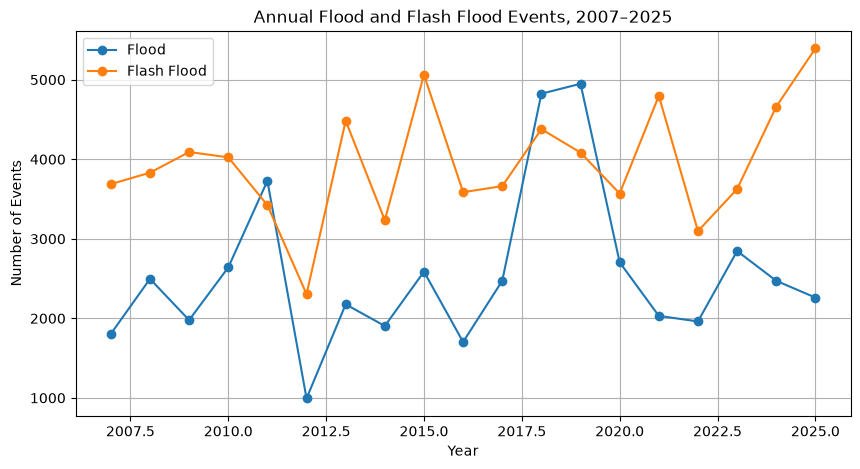

In [31]:
# Plot annual Flood and Flash Flood events

plt.figure(figsize=(10, 5))

for event_type in ["Flood", "Flash Flood"]:
    data = annual_flood_events[
        annual_flood_events["EVENT_TYPE"] == event_type
    ]
    
    plt.plot(
        data["YEAR"],
        data["event_count"],
        marker="o",
        label=event_type
    )

plt.title("Annual Flood and Flash Flood Events, 2007–2025")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(True)

plt.show()

### Annual Flood Activity

The number of Flood and Flash Flood events varies considerably from year to year between 2007 and 2025. Flash Flood events are more common in many years, although the two event types show different patterns over time. The variation across years shows that flood activity is not constant during the study period. Because national annual totals can hide differences among counties, the next step is to examine flood activity at the county level.

In [32]:
# Count annual flood events for each county

county_year_flood = (
    flood.groupby(["county_fips", "YEAR"])
    .size()
    .reset_index(name="flood_events")
)

county_year_flood.head()

,county_fips,YEAR,flood_events
0,1001,2007,1
1,1001,2009,3
2,1001,2013,1
3,1001,2014,2
4,1001,2015,2


In [33]:
# Examine the number of county-year flood records

print("Number of county-year records:", len(county_year_flood))

print("Years recorded for county 1001:")
print(
    county_year_flood[
        county_year_flood["county_fips"] == 1001
    ]
)

Number of county-year records: 31408
Years recorded for county 1001:
   county_fips  YEAR  flood_events
0         1001  2007             1
1         1001  2009             3
2         1001  2013             1
3         1001  2014             2
4         1001  2015             2
5         1001  2016             2
6         1001  2017             2
7         1001  2024             1


In [34]:
# Calculate total Flood and Flash Flood events for each county

county_flood_total = (
    flood.groupby("county_fips")
    .size()
    .reset_index(name="flood_events")
)

county_flood_total.head()

,county_fips,flood_events
0,1001,14
1,1003,104
2,1005,5
3,1007,8
4,1009,26


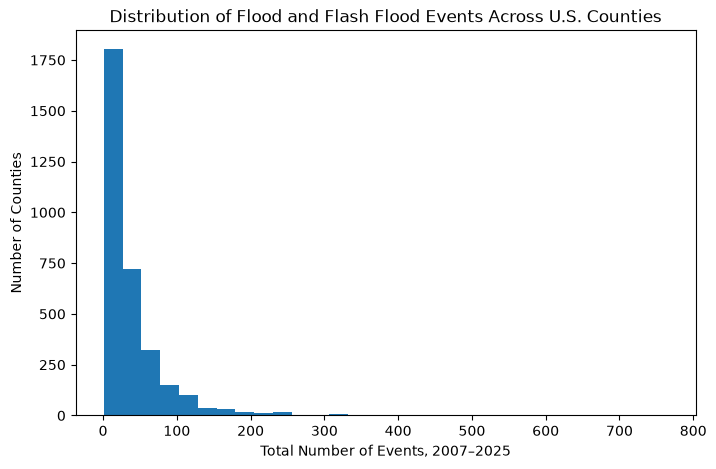

In [35]:
# Plot the distribution of total flood events across counties

plt.figure(figsize=(8, 5))

plt.hist(county_flood_total["flood_events"], bins=30)

plt.title("Distribution of Flood and Flash Flood Events Across U.S. Counties")
plt.xlabel("Total Number of Events, 2007–2025")
plt.ylabel("Number of Counties")

plt.show()

### County-Level Flood Variation
Flood activity varies substantially across U.S. counties with recorded Flood or Flash Flood events. Most counties with recorded events have relatively few events during 2007–2025, while a smaller number of counties have much higher event counts. This shows that flood activity is not evenly distributed across counties. Before comparing this variation with precipitation patterns, the county identifiers in the two datasets must first be standardized.

## 3. Data Integration and Overlap
The precipitation and flood datasets are both organized at the county level, but their geographic identifiers are not directly compatible. Before combining the datasets, I examine their temporal and spatial coverage and identify the steps needed to standardize county identifiers for the final analysis.

In [36]:
# Compare temporal coverage of the two datasets

print("Precipitation data:", prcp["year"].min(), "-", prcp["year"].max())
print("Flood data:", flood["YEAR"].min(), "-", flood["YEAR"].max())

print("Common analysis period: 2007 - 2025")

Precipitation data: 2000 - 2025
Flood data: 2007 - 2025
Common analysis period: 2007 - 2025


### Temporal Overlap

The precipitation dataset covers 2000–2025, while the Flood and Flash Flood dataset covers 2007–2025. Therefore, the two datasets overlap for 19 years, from 2007 through 2025. This common period will be used when the precipitation and flood data are combined for analysis.

In [37]:
# Compare county identifiers in the two datasets

print("Precipitation example:")
print(
    prcp[
        prcp["county"].str.startswith("AZ:")
    ][["fips", "county"]]
    .drop_duplicates()
    .head()
)

print("\nFlood example:")
print(
    flood[
        flood["STATE"] == "ARIZONA"
    ][["county_fips", "STATE", "CZ_NAME"]]
    .drop_duplicates()
    .head()
)

Precipitation example:
    fips               county
67  2001    AZ: Apache County
68  2003   AZ: Cochise County
69  2005  AZ: Coconino County
70  2007      AZ: Gila County
71  2009    AZ: Graham County

Flood example:
     county_fips    STATE   CZ_NAME
0           4025  ARIZONA   YAVAPAI
2           4001  ARIZONA    APACHE
51          4005  ARIZONA  COCONINO
52          4017  ARIZONA    NAVAJO
295         4015  ARIZONA    MOHAVE


### Geographic Identifier Compatibility

During the overlap check, I found that the county identifiers in the precipitation data do not directly match the official county FIPS codes constructed from the Storm Events data. For example, Arizona counties use different numeric prefixes in the two datasets. Because of this difference, a direct numeric merge would incorrectly match some counties and miss others. Before the final datasets are combined, I will standardize the geographic identifiers using county and state information and then verify the matches.

### Spatial Overlap

Both datasets provide county-level information, but their geographic coverage is not identical. The precipitation dataset contains 3,107 county records, while the Storm Events dataset contains broader geographic coverage, including areas not represented in the precipitation data. Therefore, the final analysis will be limited to counties that can be consistently identified in both datasets.

### Data Challenges and Roadblocks

Two main data challenges were identified during the exploratory analysis. First, the Storm Events data did not consistently report Flood events at the county level in the earlier years. Many earlier records used forecast zones instead of counties, so I selected 2007–2025 as the consistent period for county-level Flood and Flash Flood analysis. Second, the county identifiers in the two datasets are not directly compatible, as shown above. This geographic issue will need to be addressed before the datasets are combined.

### Planned Data Integration
For the final analysis, precipitation and flood data will be organized at the county-year level for the common period 2007–2025. Annual precipitation will represent precipitation conditions, while the number of Flood and Flash Flood events will represent flood activity. Before merging, the county identifiers will be standardized and the geographic matches will be checked. After the datasets are aligned, I will examine whether counties experiencing greater changes in precipitation also show changes in flood activity. The combined dataset will later be prepared for the supervised machine-learning methods covered in the course.